# Logistic Regression (From Scratch + Sklearn)
## 📊 Logistic Regression Implementation

### 📌 Objective
- Implement Logistic Regression from scratch
- Understand mathematical intuition
- Compare with Scikit-Learn implementation


### 1. Import Libraries


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
### 2. Dataset( Working and simple)

X:
 [[1]
 [2]
 [3]
 [4]
 [5]
 [6]
 [7]
 [8]]
y:
 [0 0 0 0 1 1 1 1]


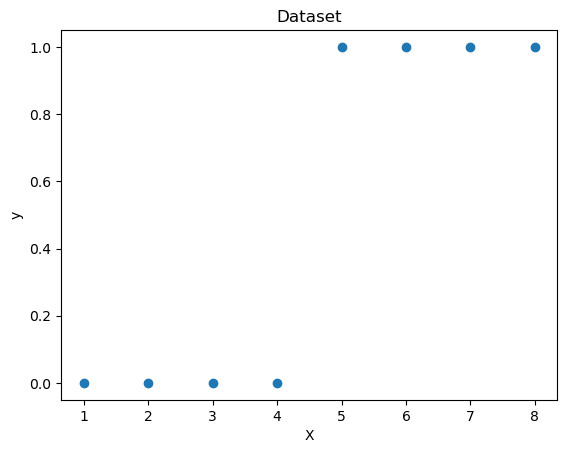

In [7]:
# Simple dataset
X = np.array([1,2,3,4,5,6,7,8])
y = np.array([0,0,0,0,1,1,1,1])

# Reshape X
X = X.reshape(-1,1)

print("X:\n", X)
print("y:\n", y)

# Plot
plt.scatter(X, y)
plt.title("Dataset")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

- The dataset is clearly separable into two classes.
- This makes it ideal for Logistic Regression.
- Sigmoid converts values into probabilities.
- Output is always between 0 and 1.

### 3. initialize parameters

In [9]:
m = 0.0
b = 0.0
learning_rate = 0.01
epochs = 1000
n = len(X)

### 4. Sigmoid function

In [11]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

### 5. Gradient descent

In [12]:
losses = []

for i in range(epochs):
    z = m * X.flatten() + b
    y_pred = sigmoid(z)
    
    # Avoid log(0)
    y_pred = np.clip(y_pred, 1e-9, 1 - 1e-9)
    
    # Loss
    loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
    losses.append(loss)
    
    # Gradients
    dm = (1/n) * np.sum((y_pred - y) * X.flatten())
    db = (1/n) * np.sum(y_pred - y)
    
    # Update
    m -= learning_rate * dm
    b -= learning_rate * db
    
    if i % 100 == 0:
        print(f"Epoch {i}, Loss: {loss}")

Epoch 0, Loss: 0.6931471805599453
Epoch 100, Loss: 0.586141507461083
Epoch 200, Loss: 0.5586337185667226
Epoch 300, Loss: 0.5335438217640947
Epoch 400, Loss: 0.5106414808656905
Epoch 500, Loss: 0.4897123216421798
Epoch 600, Loss: 0.47055847846492305
Epoch 700, Loss: 0.4529994061359914
Epoch 800, Loss: 0.43687180724177826
Epoch 900, Loss: 0.4220289603030927


- Loss decreases as training progresses.
- This shows the model is learning correctly.

### 6. PLot loss

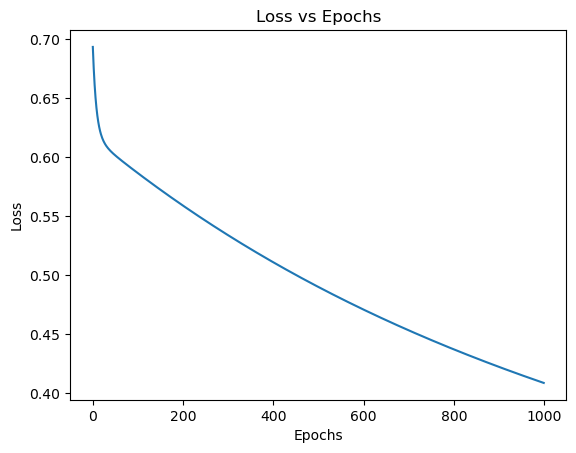

In [13]:
plt.plot(losses)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

### 7. Prediction

In [14]:
z = m * X + b
probs = sigmoid(z)

predictions = (probs >= 0.5).astype(int)

print("Probabilities:", probs)
print("Predictions:", predictions)

Probabilities: [[0.27992304]
 [0.37422469]
 [0.47915543]
 [0.58595825]
 [0.68524677]
 [0.77006858]
 [0.83745421]
 [0.88796442]]
Predictions: [[0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]]


- Values above 0.5 are classified as 1.
- Model correctly separates classes.

### 8. Visualization

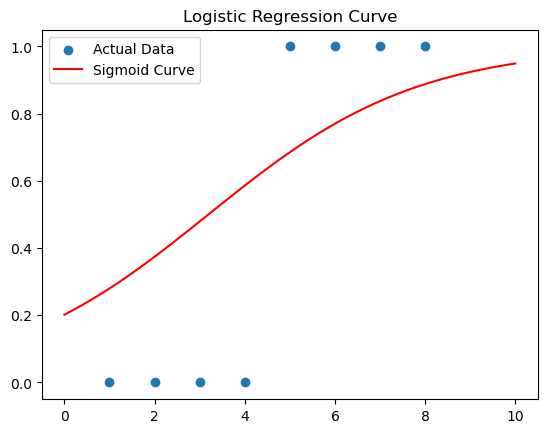

In [15]:
plt.scatter(X, y, label="Actual Data")

x_vals = np.linspace(0,10,100)
y_vals = sigmoid(m * x_vals + b)

plt.plot(x_vals, y_vals, color='red', label="Sigmoid Curve")

plt.legend()
plt.title("Logistic Regression Curve")
plt.show()

- The sigmoid curve shows probability transition.
- Clear boundary between two classes.

### 9. Scikit learn COmparison

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y)

sk_preds = model.predict(X)

print("Sklearn Predictions:", sk_preds)
print("Our Predictions:", predictions)

Sklearn Predictions: [0 0 0 0 1 1 1 1]
Our Predictions: [[0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]]


- Predictions are very similar.
- Confirms correctness of implementation.

### 10. Key learnings

- Logistic Regression is used for classification
- Sigmoid converts output into probability
- Gradient Descent minimizes loss
- Learning rate affects convergence